# Simulate a micrograph with continuum ice

Same apoferritin (**6DRV**) pipeline as `simulate_micrograph_from_pdb.ipynb`, but compares three solvent treatments from `torch-calculate-electrostatic-potential`:

| Label | Call | What it does |
|-------|------|--------------|
| `none` | `model_water_potential=False` | Dry atoms only (vacuum around the protein) |
| `constant` | `model_water_potential=True, solvent_model="constant"` | Flat bulk ice outside a VdW + probe exclusion mask |
| `shang_sigworth` | `model_water_potential=True` (default model) | Shang & Sigworth (2012) continuum hydration density × ice MIP |

For each case we build the 3D ESP (volts), run multislice, and form a noise-free micrograph so solvent contrast is easy to see.

For a multi-particle ice slab and Y-tilt series, see [`simulate_tilt_series_slab.ipynb`](simulate_tilt_series_slab.ipynb).

In [1]:
import mmdf
import torch
from matplotlib import pyplot as plt
from torch_calculate_electrostatic_potential import (
    GridConfig,
    default_sublattice_radius,
    solvated_potential_from_structure_3d,
)
from torch_scattering import multislice
from torch_structure_manipulation import (
    AtomicStructure,
    annotate_bonding_environments,
    apply_rotation,
    center_structure,
    create_rotation_matrix_from_euler,
)

from torch_simulate_image import (
    CtfConfig,
    FluenceConfig,
    MicrographSimulationConfig,
    PoissonConfig,
    simulate_micrograph,
)

## Simulation parameters

In [8]:
PIXEL_SIZE = 2.0  # Å — coarse for a fast demo
VOLTAGE_KV = 300.0
PADDING_A = 20.0  # extra ice around the molecule
ICE_POTENTIAL_V = 3.6  # bulk amorphous-ice MIP (volts)
PROBE_RADIUS = 1.4  # Å; excluded radius = VdW + probe_radius
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# (label, kwargs for solvated_potential_from_structure_3d)
SOLVENT_CASES = (
    ("none", {"model_water_potential": False}),
    ("constant", {"model_water_potential": True, "solvent_model": "constant"}),
    ("shang_sigworth", {"model_water_potential": True}),  # default solvent_model
)
DEVICE

device(type='cuda')

## 1. Structure (6DRV)

Download, annotate bonding, center, and rotate — same prep as the dry notebook.

In [9]:
atoms = mmdf.read("pdb:6drv")
annotated = annotate_bonding_environments(atoms, include_hydrogens=False)
centered = center_structure(annotated, center_point=(0.0, 0.0, 0.0), zyx=False)
rotation = create_rotation_matrix_from_euler(
    torch.tensor([0.0, 30.0, 0.0]),
    order="ZYZ",
    degrees=True,
)
posed = apply_rotation(centered, rotation, zyx=False)
structure = AtomicStructure.from_dataframe(posed, device=DEVICE)
print(f"{structure.num_atoms} atoms on {structure.device}")

32888 atoms on cuda:0


## 2. Shared grid

One cubic grid for all solvent models so slices and micrographs line up. Extra padding leaves room for bulk ice.

In [10]:
positions = structure.positions_zyx
mins = positions.amin(dim=0) - PADDING_A
maxs = positions.amax(dim=0) + PADDING_A

grid = GridConfig.from_voxel_size_and_corner_points(
    voxel_size=(PIXEL_SIZE, PIXEL_SIZE, PIXEL_SIZE),
    left_bottom_point=tuple(mins.tolist()),
    right_upper_point=tuple(maxs.tolist()),
    sublattice_radius=default_sublattice_radius(PIXEL_SIZE),
    device=DEVICE,
)
print("grid shape (Z,Y,X):", tuple(int(n) for n in grid.grid_shape.tolist()))

grid shape (Z,Y,X): (211, 211, 211)


## 3. ESP for each solvent model

`solvated_potential_from_structure_3d(..., model_water_potential=True)` adds continuum ice (in volts) on top of the dry atomic potential. With water on, the default model is Shang–Sigworth.

building ESP: solvent_model='none' …


/home/jdickerson/git/teamtomo/teamtomo_main/teamtomo/packages/primitives/torch-calculate-electrostatic-potential/src/torch_calculate_electrostatic_potential/structure.py:140: UserWarning: unsupported bonded scattering parameters (atom 4: protein key 'C(CC)'; atom 5: protein key 'C(CS)'; atom 7: protein key 'C(S)'; and 9737 more); using elemental fallback
  return resolve_scattering_parameters(


building ESP: solvent_model='constant' …
building ESP: solvent_model='shang_sigworth' …


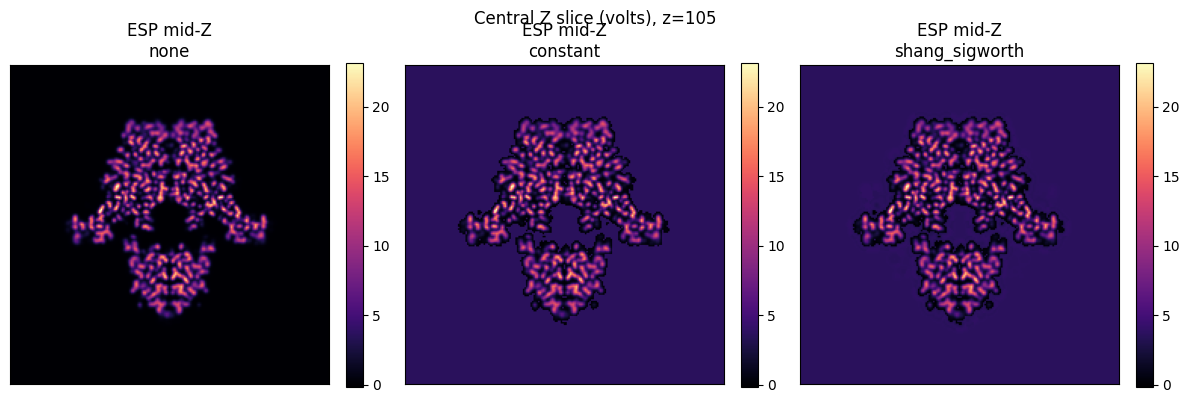

none              mean=  0.375 V  std=  1.768 V  corner=  0.000 V
constant          mean=  3.695 V  std=  1.253 V  corner=  3.600 V
shang_sigworth    mean=  3.698 V  std=  1.253 V  corner=  3.600 V


In [11]:
potentials = {}
for label, solvent_kwargs in SOLVENT_CASES:
    print(f"building ESP: {label!r} …")
    potentials[label] = solvated_potential_from_structure_3d(
        structure,
        grid,
        ice_potential_V=ICE_POTENTIAL_V,
        probe_radius=PROBE_RADIUS,
        scattering_factors="peng_bonded",
        bonded_fallback="elemental",
        **solvent_kwargs,
    )

labels = [label for label, _ in SOLVENT_CASES]
mid_z = potentials["none"].shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, label in zip(axes, labels):
    im = ax.imshow(potentials[label][mid_z].detach().cpu().numpy(), cmap="magma")
    ax.set_title(f"ESP mid-Z\n{label}")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"Central Z slice (volts), z={mid_z}")
plt.tight_layout()
plt.show()

for label, pot in potentials.items():
    print(
        f"{label:16s}  mean={float(pot.mean()):7.3f} V  "
        f"std={float(pot.std()):7.3f} V  corner={float(pot[0, 0, 0]):7.3f} V"
    )

## 4. Multislice → micrograph

Same optics for every solvent model. Poisson is off so differences come from ice contrast, not noise draws.

multislice + micrograph: 'none' …
multislice + micrograph: 'constant' …
multislice + micrograph: 'shang_sigworth' …


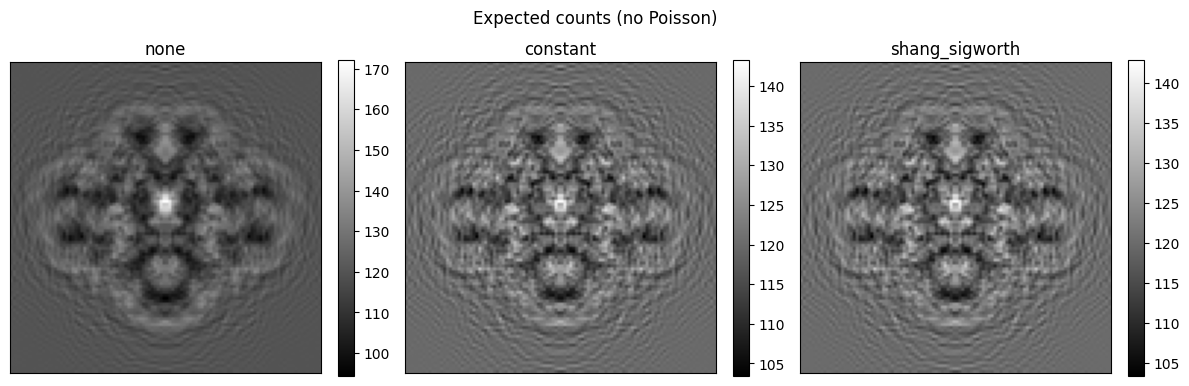

In [6]:
config = MicrographSimulationConfig(
    pixel_size=PIXEL_SIZE,
    ctf=CtfConfig(defocus_um=1.5, voltage_kv=VOLTAGE_KV),
    fluence=FluenceConfig(dose_e_per_A2=30.0),
    poisson=PoissonConfig(apply=False),
)

micrographs = {}
for label, pot in potentials.items():
    print(f"multislice + micrograph: {label!r} …")
    exit_wave = multislice(pot, pixel_size=PIXEL_SIZE, voltage=VOLTAGE_KV)
    micrographs[label] = simulate_micrograph(exit_wave, config)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, label in zip(axes, labels):
    im = ax.imshow(micrographs[label].detach().cpu().numpy(), cmap="gray")
    ax.set_title(label)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Expected counts (no Poisson)")
plt.tight_layout()
plt.show()

## 5. Difference maps

Subtract the dry micrograph to highlight what continuum ice changes.

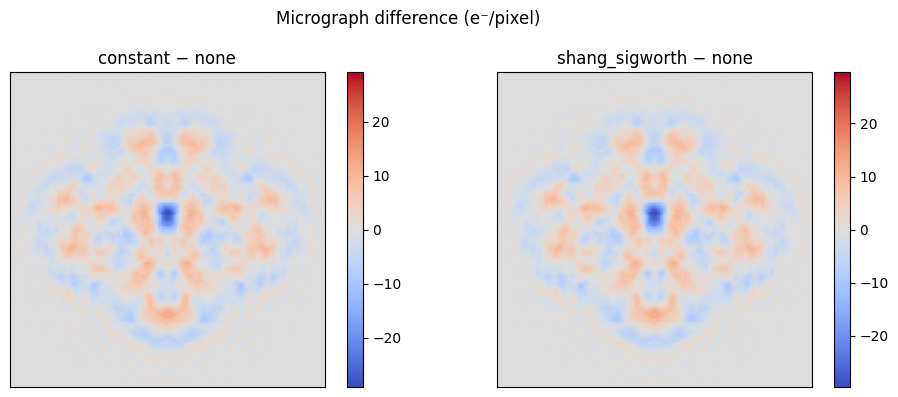

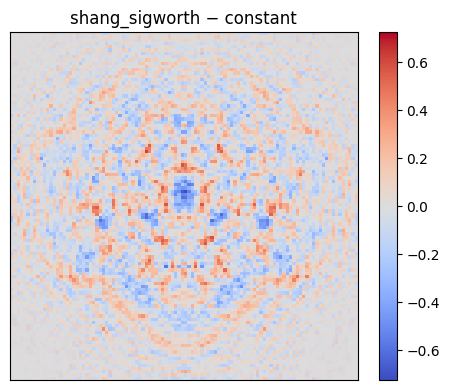

In [7]:
dry = micrographs["none"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model in zip(axes, ("constant", "shang_sigworth")):
    diff = (micrographs[model] - dry).detach().cpu().numpy()
    vmax = max(abs(diff.min()), abs(diff.max()), 1e-6)
    im = ax.imshow(diff, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{model} − none")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Micrograph difference (e⁻/pixel)")
plt.tight_layout()
plt.show()

ss_minus_const = (
    micrographs["shang_sigworth"] - micrographs["constant"]
).detach().cpu().numpy()
vmax = max(abs(ss_minus_const.min()), abs(ss_minus_const.max()), 1e-6)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(ss_minus_const, cmap="coolwarm", vmin=-vmax, vmax=vmax)
ax.set_title("shang_sigworth − constant")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()